In [1]:
# ===================================================================
# PHASE 1: SETUP & IMPORTS
# ===================================================================
# No external installs are needed for this model.
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

In [2]:
# ===================================================================
# PHASE 2: CONFIGURATION
# ===================================================================

# --- IMPORTANT: Update this path to your features directory ---
FEATURES_DIR = "/kaggle/input/phase-01/features/"

# --- Model & Training Hyperparameters ---
FIXED_SEQUENCE_LENGTH = 100 
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0005 # GRUs can be sensitive to learning rate
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"All sequences will be padded/truncated to {FIXED_SEQUENCE_LENGTH} frames.")

Using device: cuda
All sequences will be padded/truncated to 100 frames.


In [3]:
# ===================================================================
# PHASE 3: CUSTOM PYTORCH DATASET (No changes needed)
# ===================================================================

class FeatureDataset(Dataset):
    """Custom Dataset for loading feature sequences."""
    def __init__(self, file_paths, sequence_length):
        self.file_paths = file_paths
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        features = np.load(file_path)
        
        if features.shape[0] > self.sequence_length:
            features = features[:self.sequence_length]
        else:
            padding = np.zeros((self.sequence_length - features.shape[0], features.shape[1]))
            features = np.vstack((features, padding))
            
        label = 0 if "Normal" in os.path.basename(file_path) else 1
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [4]:
# ===================================================================
# PHASE 4: PREPARE DATA & DATALOADERS (No changes needed)
# ===================================================================

print("\nPreparing data loaders...")
all_feature_files = [os.path.join(FEATURES_DIR, f) for f in os.listdir(FEATURES_DIR) if f.endswith('.npy')]
train_files, val_files = train_test_split(all_feature_files, test_size=0.2, random_state=42)
train_dataset = FeatureDataset(train_files, FIXED_SEQUENCE_LENGTH)
val_dataset = FeatureDataset(val_files, FIXED_SEQUENCE_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"   - Training on {len(train_files)} videos, validating on {len(val_files)} videos.")

labels = [0 if "Normal" in f else 1 for f in all_feature_files]
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Calculated class weights to handle imbalance: {class_weights}")


Preparing data loaders...
   - Training on 440 videos, validating on 110 videos.
Calculated class weights to handle imbalance: tensor([1.8333, 0.6875], device='cuda:0')


In [5]:
# ===================================================================
# PHASE 5: GRU MODEL ARCHITECTURE
# ===================================================================

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True, # This is important for our data shape
            dropout=dropout,
            bidirectional=True # Bidirectional GRU often performs better
        )
        # The input to the linear layer is hidden_size * 2 because it's bidirectional
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        # gru_out shape: (batch_size, sequence_length, hidden_size * 2)
        # h_n shape: (num_layers * 2, batch_size, hidden_size)
        gru_out, _ = self.gru(x)
        
        # We take the output of the last time step
        last_time_step_out = gru_out[:, -1, :]
        
        out = self.linear(last_time_step_out)
        return out

In [6]:
# Model parameters
INPUT_FEATURES = 1280
HIDDEN_SIZE = 256
NUM_LAYERS = 2
NUM_CLASSES = 2
DROPOUT = 0.3

model = GRUModel(INPUT_FEATURES, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(DEVICE)
print("\nModel Architecture:")
print(model)


Model Architecture:
GRUModel(
  (gru): GRU(1280, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (linear): Linear(in_features=512, out_features=2, bias=True)
)


In [7]:
# # ===================================================================
# # PHASE 6: TRAINING LOOP (No changes needed)
# # ===================================================================

# criterion = nn.CrossEntropyLoss(weight=class_weights)
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# best_val_accuracy = 0.0

# print("\nStarting model training...")

# for epoch in range(EPOCHS):
#     model.train()
#     running_loss, correct_predictions, total_samples = 0.0, 0, 0
#     train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
#     for inputs, labels in train_pbar:
#         inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item() * inputs.size(0)
#         _, predicted = torch.max(outputs.data, 1)
#         total_samples += labels.size(0)
#         correct_predictions += (predicted == labels).sum().item()
#         train_pbar.set_postfix({'loss': loss.item(), 'acc': (predicted == labels).sum().item()/labels.size(0)})

#     epoch_loss = running_loss / total_samples
#     epoch_acc = correct_predictions / total_samples
    
#     model.eval()
#     val_correct_predictions, val_total_samples = 0, 0
#     with torch.no_grad():
#         for inputs, labels in val_loader:
#             inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs.data, 1)
#             val_total_samples += labels.size(0)
#             val_correct_predictions += (predicted == labels).sum().item()

#     val_epoch_acc = val_correct_predictions / val_total_samples
#     print(f"Epoch {epoch+1}/{EPOCHS} -> Train Acc: {epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")
    
#     if val_epoch_acc > best_val_accuracy:
#         best_val_accuracy = val_epoch_acc
#         torch.save(model.state_dict(), 'best_gru_model.pth')
#         print(f"   -> New best model saved with validation accuracy: {best_val_accuracy:.4f}")

# print("\n\nTraining complete!")
# print(f"The best model was saved as 'best_gru_model.pth' with an accuracy of {best_val_accuracy:.4f}")

In [8]:
# ===================================================================
# PHASE 6: TRAINING LOOP (Modified to track history)
# ===================================================================

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
best_val_accuracy = 0.0

# --- History tracking lists ---
# <-- ADD THIS (4 lines)
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

print("\nStarting model training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_predictions, total_samples = 0.0, 0, 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
        train_pbar.set_postfix({'loss': loss.item(), 'acc': (predicted == labels).sum().item()/labels.size(0)})

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    
    # <-- ADD THIS (2 lines)
    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)
    
    model.eval()
    val_correct_predictions, val_total_samples = 0, 0
    val_running_loss = 0.0 # <-- ADD THIS
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            
            # --- Calculate validation loss ---
            # <-- ADD THIS (2 lines)
            val_loss = criterion(outputs, labels)
            val_running_loss += val_loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            val_total_samples += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    val_epoch_acc = val_correct_predictions / val_total_samples
    val_epoch_loss = val_running_loss / val_total_samples # <-- ADD THIS
    
    # <-- ADD THIS (2 lines)
    val_loss_history.append(val_epoch_loss)
    val_acc_history.append(val_epoch_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Acc: {epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f}")
    
    if val_epoch_acc > best_val_accuracy:
        best_val_accuracy = val_epoch_acc
        torch.save(model.state_dict(), 'best_gru_model.pth')
        print(f"   -> New best model saved with validation accuracy: {best_val_accuracy:.4f}")

print("\n\nTraining complete!")
print(f"The best model was saved as 'best_gru_model.pth' with an accuracy of {best_val_accuracy:.4f}")


Starting model training...


Epoch 1/20 [Train]: 100%|██████████| 14/14 [00:04<00:00,  3.21it/s, loss=0.697, acc=0.333]


Epoch 1/20 -> Train Acc: 0.6659 | Val Acc: 0.5636 | Train Loss: 0.6722 | Val Loss: 0.6000
   -> New best model saved with validation accuracy: 0.5636


Epoch 2/20 [Train]: 100%|██████████| 14/14 [00:01<00:00, 12.85it/s, loss=0.582, acc=0.5]


Epoch 2/20 -> Train Acc: 0.5614 | Val Acc: 0.6091 | Train Loss: 0.5343 | Val Loss: 0.5387
   -> New best model saved with validation accuracy: 0.6091


...

Epoch 18/20 -> Train Acc: 0.9568 | Val Acc: 0.8545 | Train Loss: 0.1176 | Val Loss: 0.4935


Epoch 19/20 [Train]: 100%|██████████| 14/14 [00:01<00:00, 13.76it/s, loss=0.0143, acc=1]


Epoch 19/20 -> Train Acc: 0.9523 | Val Acc: 0.8273 | Train Loss: 0.1362 | Val Loss: 0.5478


Epoch 20/20 [Train]: 100%|██████████| 14/14 [00:01<00:00, 13.76it/s, loss=0.0966, acc=0.958]


Epoch 20/20 -> Train Acc: 0.9636 | Val Acc: 0.8636 | Train Loss: 0.1269 | Val Loss: 0.5823


Training complete!
The best model was saved as 'best_gru_model.pth' with an accuracy of 0.8818


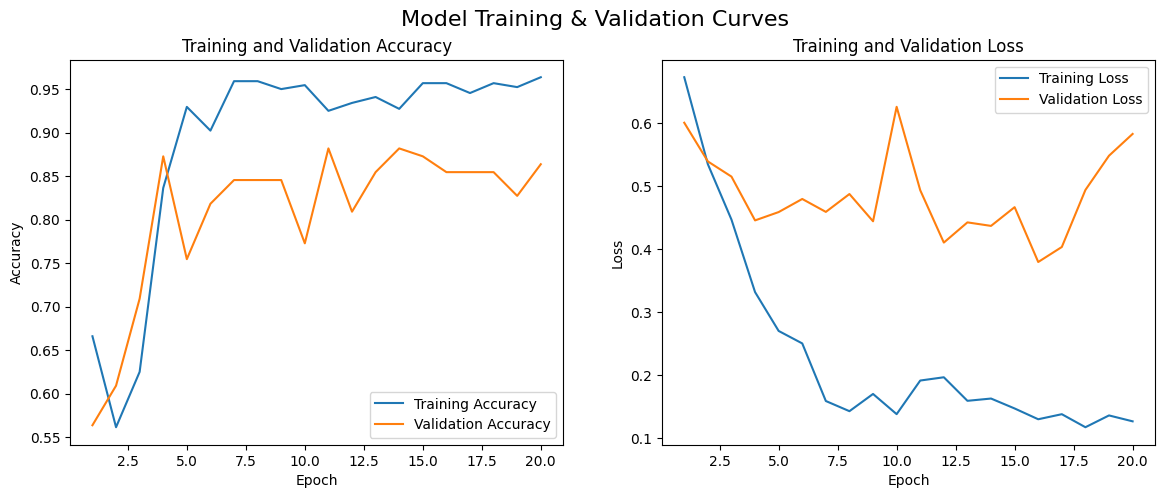

In [9]:
# ===================================================================
# PHASE 7: PLOT TRAINING & VALIDATION CURVES
# ===================================================================
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# --- Plot Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc_history, label='Training Accuracy')
plt.plot(epochs_range, val_acc_history, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss_history, label='Training Loss')
plt.plot(epochs_range, val_loss_history, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.suptitle('Model Training & Validation Curves', fontsize=16)
plt.show()

In [10]:
# Add these to your existing imports cell at the top
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# <-- ADD THIS (4 lines)
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from torch.nn.functional import softmax

In [11]:
print("\n\n--- Starting Final Evaluation on Best Model ---")

# 1. Load the best performing model's weights
model.load_state_dict(torch.load('best_gru_model.pth', map_location=DEVICE))




--- Starting Final Evaluation on Best Model ---


<All keys matched successfully>

In [12]:
# 2. Set the model to evaluation mode
model.eval()

GRUModel(
  (gru): GRU(1280, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (linear): Linear(in_features=512, out_features=2, bias=True)
)

In [13]:
# 3. Prepare lists to store all predictions and labels
all_predictions = []
all_labels = []
all_probs = [] # <-- ADD THIS

In [14]:
# # 4. Run inference on the validation set (no gradients needed)
# with torch.no_grad():
#     for inputs, labels in tqdm(val_loader, desc="Evaluating on Validation Set"):
#         inputs = inputs.to(DEVICE)
#         outputs = model(inputs)
#         _, predicted = torch.max(outputs.data, 1)
        
#         all_predictions.extend(predicted.cpu().numpy())
#         all_labels.extend(labels.numpy())

In [15]:
# 4. Run inference on the validation set (no gradients needed)
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Evaluating on Validation Set"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        
        # --- Get probabilities for ROC/PR ---
        # <-- ADD THIS (2 lines)
        probabilities = softmax(outputs, dim=1)
        positive_class_probs = probabilities[:, 1] # Get probs for 'Anomaly' (Class 1)

        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(positive_class_probs.cpu().numpy()) # <-- ADD THIS

Evaluating on Validation Set: 100%|██████████| 4/4 [00:00<00:00, 21.13it/s]


In [16]:
# --- 5. Print the Classification Report ---
print("\n--- Classification Report ---")
class_names = ['Normal (Class 0)', 'Anomaly (Class 1)']
print(classification_report(all_labels, all_predictions, target_names=class_names))


--- Classification Report ---
                   precision    recall  f1-score   support

 Normal (Class 0)       0.74      0.86      0.79        29
Anomaly (Class 1)       0.95      0.89      0.92        81

         accuracy                           0.88       110
        macro avg       0.84      0.88      0.86       110
     weighted avg       0.89      0.88      0.88       110




--- Confusion Matrix ---


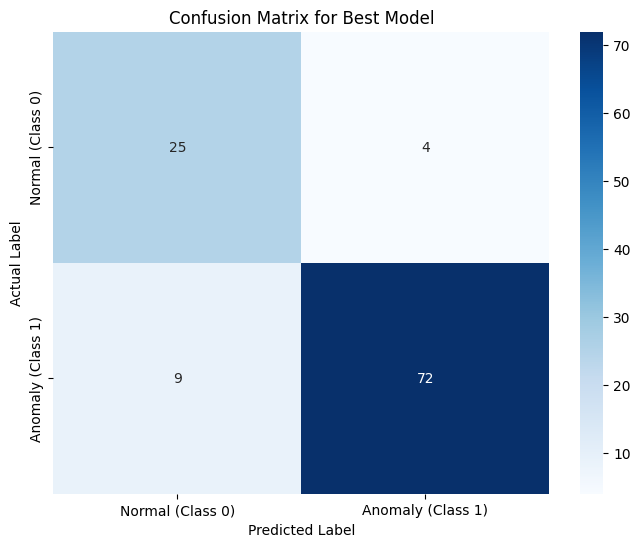

In [17]:
# --- 6. Display the Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Best Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

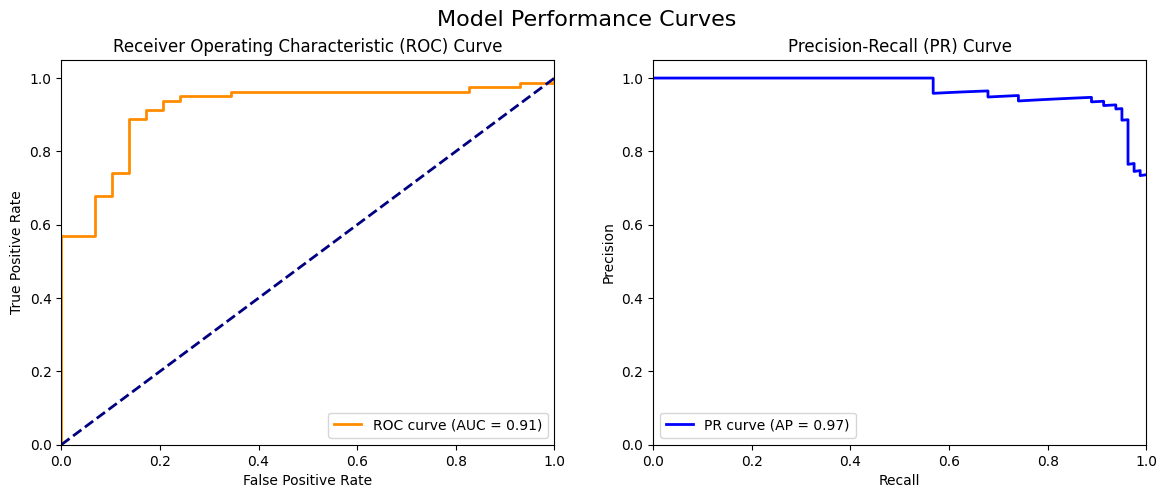

In [18]:
# ===================================================================
# PHASE 10: PLOT ROC and PRECISION-RECALL (PR) CURVES
# ===================================================================

# Ensure labels are numpy arrays
y_true = np.array(all_labels)
y_probs = np.array(all_probs)

# --- Define class names (already in your notebook) ---
# class_names = ['Normal (Class 0)', 'Anomaly (Class 1)']

# --- Calculate ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# --- Calculate Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true, y_probs)
avg_precision = average_precision_score(y_true, y_probs)

# --- Plotting ---
plt.figure(figsize=(14, 5))

# --- ROC Curve Plot ---
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# --- Precision-Recall Curve Plot ---
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall (PR) Curve')
plt.legend(loc="lower left")

plt.suptitle('Model Performance Curves', fontsize=16)
plt.show()